<a href="https://colab.research.google.com/github/redrosesarecool/staz/blob/main/Classifier_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRZYKŁADY


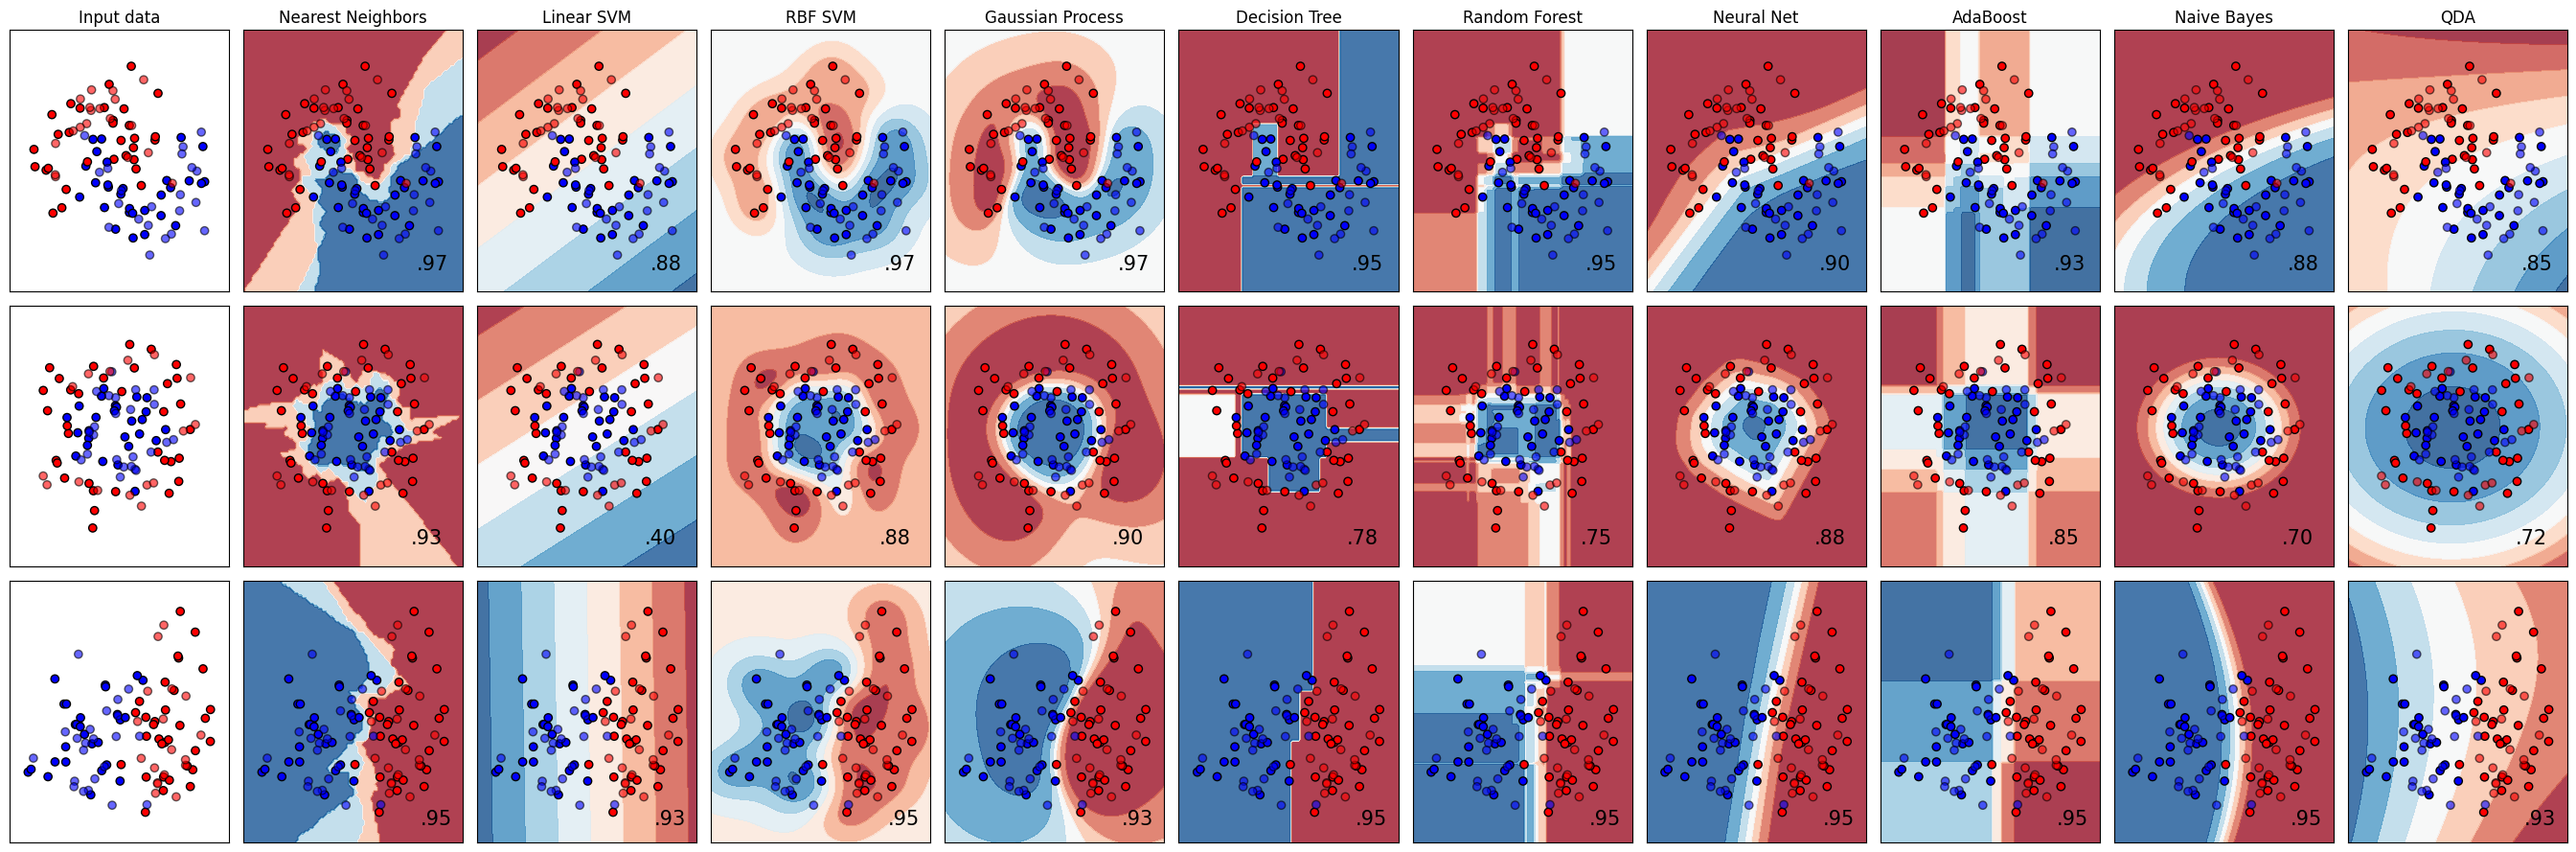

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=42
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(random_state=42),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]

figure = plt.figure(figsize=(27, 9))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        )

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout()
plt.show()

# RANDOM FOREST - R, V, z


In [ ]:
import pandas as pd

file_path = "/content/drive/My Drive/r_v_montecarlo.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)
print(df_all.head())

/tmp/ipython-input-904907318.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


         R          V
0  2.16208  205.52478
1  2.30257  200.57954
2  2.44236  196.41595
3  2.58141  197.63277
4  2.71967  197.12877


/tmp/ipython-input-2477429869.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


Accuracy Test: 0.8479809976247031
Accuracy Train: 0.8818135506877228


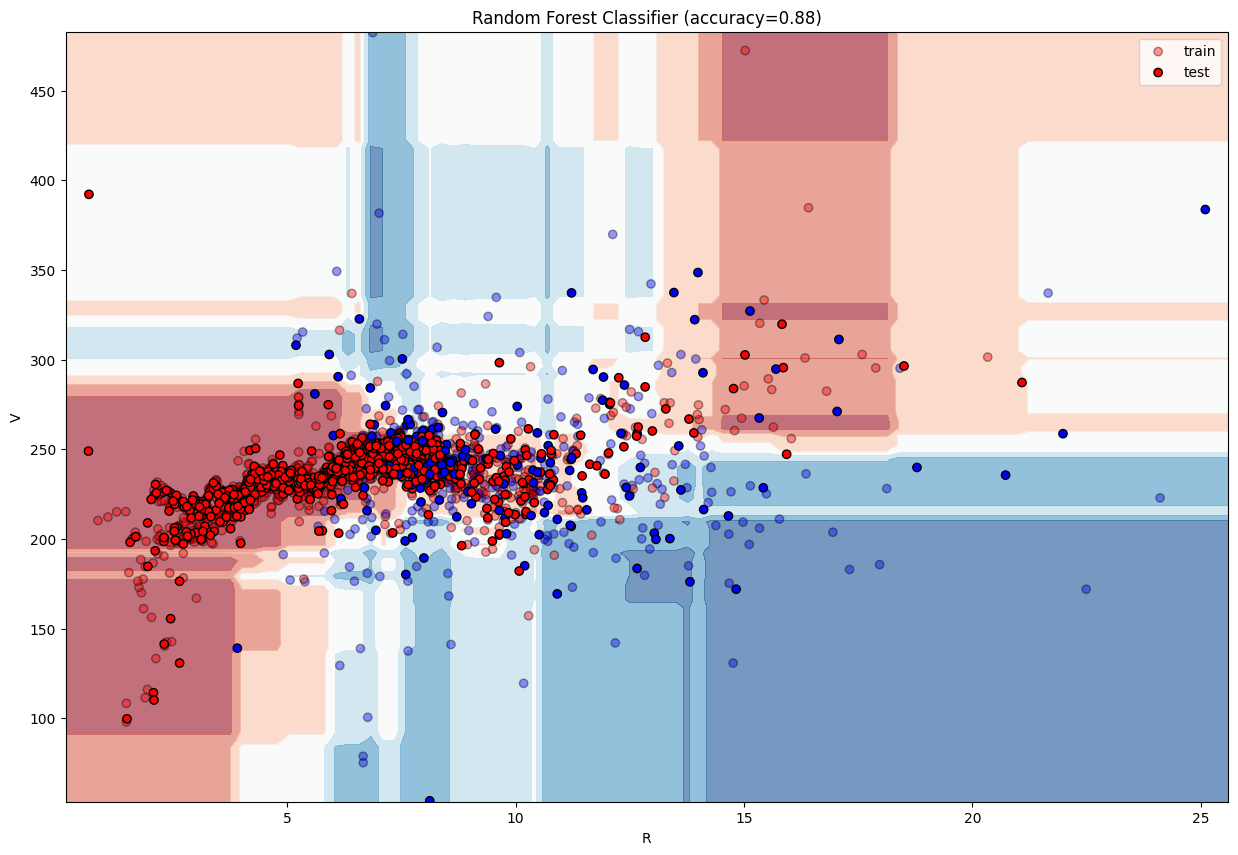

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import DecisionBoundaryDisplay

# dane
file_path = "/content/drive/My Drive/r_v_montecarlo.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)

# dane wejściowe: R, V
X = df_all[['R', 'V']].values

# klasy
y = np.zeros(len(df_all), dtype=int)   # klasa 0
y[2217:2723] = 1                       # poprawne gwiazdy klasa 1

# podział na train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# random forest classifier
clf = make_pipeline(StandardScaler(),
                    RandomForestClassifier(
                        n_estimators=10, # liczba drzew w lesie, więcej drzew to stabilniejszy wynik, ale wolniejsze uczenie
                        max_depth=5, # maksymalna głębokość drzewa
                        random_state=42 # ziarno generatora losowego
                    ))
clf.fit(X_train, y_train) # uczenie modelu na danych treningowyc
score = clf.score(X_test, y_test) # zwraca accuracy
print("Accuracy Test:", score)

score = clf.score(X_train, y_train) # zwraca accuracy
print("Accuracy Train:", score)

# rysowanie granicy decyzyjnej
cm = plt.cm.RdBu # uciągła kolorowa mapa, gradient od czerwonego do niebieskiego
cm_bright = ListedColormap(["#FF0000", "#0000FF"])  # 0= czerwony, 1= niebieski

fig, ax = plt.subplots(figsize=(15,10))

DecisionBoundaryDisplay.from_estimator(
    clf, X, cmap=cm, alpha=0.6, ax=ax, eps=0.5
) # rysuje kolorowe tło pokazujące, jak model dzieli dane na klasy

# punkty treningowe i testowe
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k", alpha=0.4, label="train")
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, edgecolors="k", label="test")

ax.set_xlabel("R")
ax.set_ylabel("V")
ax.set_title(f"Random Forest Classifier (accuracy={score:.2f})")
ax.legend()
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# dane
file_path = "/content/drive/My Drive/r_v_z.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)

# dane wejściowe: R, V, z
X = df_all[['R', 'V', 'z']].values

# klasy
y = np.zeros(len(df_all), dtype=int)
y[2217:2723] = 1

# podział na train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# model random forest w 3d
clf = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=50, # liczba drzew w lesie, więcej drzew to stabilniejszy wynik, ale wolniejsze uczenie
        max_depth=5, # maksymalna głębokość drzewa
        random_state=42 # ziarno generatora losowego
    )
)
clf.fit(X_train, y_train) # uczenie modelu na danych treningowyc
score = clf.score(X_test, y_test) # zwraca accuracy
print("Accuracy Test:", score)

score = clf.score(X_train, y_train) # zwraca accuracy
print("Accuracy Train:", score)

# predykcje
y_pred = clf.predict(X) #każdy element to etykieta klasy przewidzianej przez model
unique, counts = np.unique(y_pred, return_counts=True) # zwraca wartości w tablicy oraz ich liczność
class_distribution = dict(zip(unique, counts)) # łączy wartości i robi z nich slownik
print("Rozkład klas wg modelu:", class_distribution)

#wykres 3d

df_all_plot = df_all.copy()
df_all_plot["y_pred"] = y_pred

color_map = {0: "red", 1: "blue"}

fig = px.scatter_3d(
    df_all_plot,
    x="R",
    y="V",
    z="z",
    color=df_all_plot["y_pred"].map(color_map),
    color_discrete_map={"red": "red", "blue": "blue"},
    title=f"Random Forest 3D (accuracy={score:.2f})",
    hover_data={"R": True, "V": True, "z": True}
)

# wygląd punktów
fig.update_traces(
    marker=dict(size=4, line=dict(width=0.5, color="black"), opacity=0.8)
)

# opis osi i legenda
fig.update_layout(
    scene=dict(
        xaxis_title="x [kpc]",
        yaxis_title="y [kpc]",
        zaxis_title="z [kpc]",
    ),
    legend_title_text="Klasa",

)

txt = "<br>".join([f"Klasa {k}: {v} punktów" for k, v in class_distribution.items()])
fig.add_annotation(
    text=txt,
    xref="paper", yref="paper",
    x=0, y=1.05,
    showarrow=False,
    font=dict(size=12, color="white")
)

fig.show()



/tmp/ipython-input-2687747079.py:14: FutureWarning:

The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead



Accuracy Test: 0.8741092636579573
Accuracy Train: 0.9006622516556292
Rozkład klas wg modelu: {np.int64(0): np.int64(2500), np.int64(1): np.int64(305)}


# RANDOM FOREST - x, y, z

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

file_path = "/content/drive/My Drive/dane_obserwacyjne-kopia.dat"

# wczytanie linii z nagłówkami
with open(file_path) as f:
    lines = f.readlines()

# usunięcia nagłówka
header_line = [i for i, line in enumerate(lines) if line.strip().startswith("# R[kpc]")][0]
columns = lines[header_line].strip("# ").split()

# dane od następnej linii po nagłówku
df_all = pd.read_csv(file_path, sep=r"\s+", comment="#", names=columns, skiprows=header_line+1)
print(" Kolumny:", df_all.columns.tolist())

# dane
features = ["x[kpc]", "y[kpc]", "z[kpc]", "vRt[km/s]", "vz[km/s]"]
X = df_all[features].values

# klasy
y = np.zeros(len(df_all), dtype=int)
y[2217:2723] = 1

# podział na train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# model random forest w 3d
clf = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=50, # liczba drzew w lesie, więcej drzew to stabilniejszy wynik, ale wolniejsze uczenie
        max_depth=5, # maksymalna głębokość drzewa
        random_state=42 # ziarno generatora losowego
    )
)
clf.fit(X_train, y_train) # uczenie modelu na danych treningowyc
score = clf.score(X_test, y_test) # zwraca accuracy
print("Accuracy Test:", score)

score = clf.score(X_train, y_train) # zwraca accuracy
print("Accuracy Train:", score)

# predykcje
y_pred = clf.predict(X) #każdy element to etykieta klasy przewidzianej przez model
unique, counts = np.unique(y_pred, return_counts=True) # zwraca wartości w tablicy oraz ich liczność
class_distribution = dict(zip(unique, counts)) # łączy wartości i robi z nich slownik
print("Rozkład klas wg modelu:", class_distribution)


#wykres 3d
color_map = {0: "red", 1: "blue"}

fig = px.scatter_3d(
    df_plot,
    x="x[kpc]",
    y="y[kpc]",
    z="z[kpc]",
    color=df_plot["y_pred"].map(color_map),
    color_discrete_map={"red": "red", "blue": "blue"},
    title=f"Random Forest 3D (accuracy={score:.2f})",
    hover_data={"x[kpc]": True, "y[kpc]": True, "z[kpc]": True}
)

# wygląd punktów
fig.update_traces(
    marker=dict(size=4, line=dict(width=0.5, color="black"), opacity=0.8)
)

# opis osi i legenda
fig.update_layout(
    scene=dict(
        xaxis_title="x [kpc]",
        yaxis_title="y [kpc]",
        zaxis_title="z [kpc]",
    ),
    legend_title_text="Klasa",

)

txt = "<br>".join([f"Klasa {k}: {v} punktów" for k, v in class_distribution.items()])
fig.add_annotation(
    text=txt,
    xref="paper", yref="paper",
    x=0, y=1.05,
    showarrow=False,
    font=dict(size=12, color="white")
)

fig.show()

 Kolumny: ['R[kpc]', 'err_R[kpc]', 'D[kpc]', 'err_D[kpc]', 'l[deg]', 'b[deg]', 'x[kpc]', 'y[kpc]', 'z[kpc]', 'vx[km/s]', 'vRt[km/s]', 'err_vRt[km/s]', 'vz[km/s]', 'wc[km/s/kpc]', 'delta_wc[km/s/kpc]', 'Reference']
Accuracy Test: 0.8770883054892601
Accuracy Train: 0.9140225179119754
Rozkład klas wg modelu: {np.int64(0): np.int64(2467), np.int64(1): np.int64(325)}


# NEURAL NETWORK - R, V, z

/tmp/ipython-input-2911086943.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


Accuracy (MLP): 0.8622327790973872


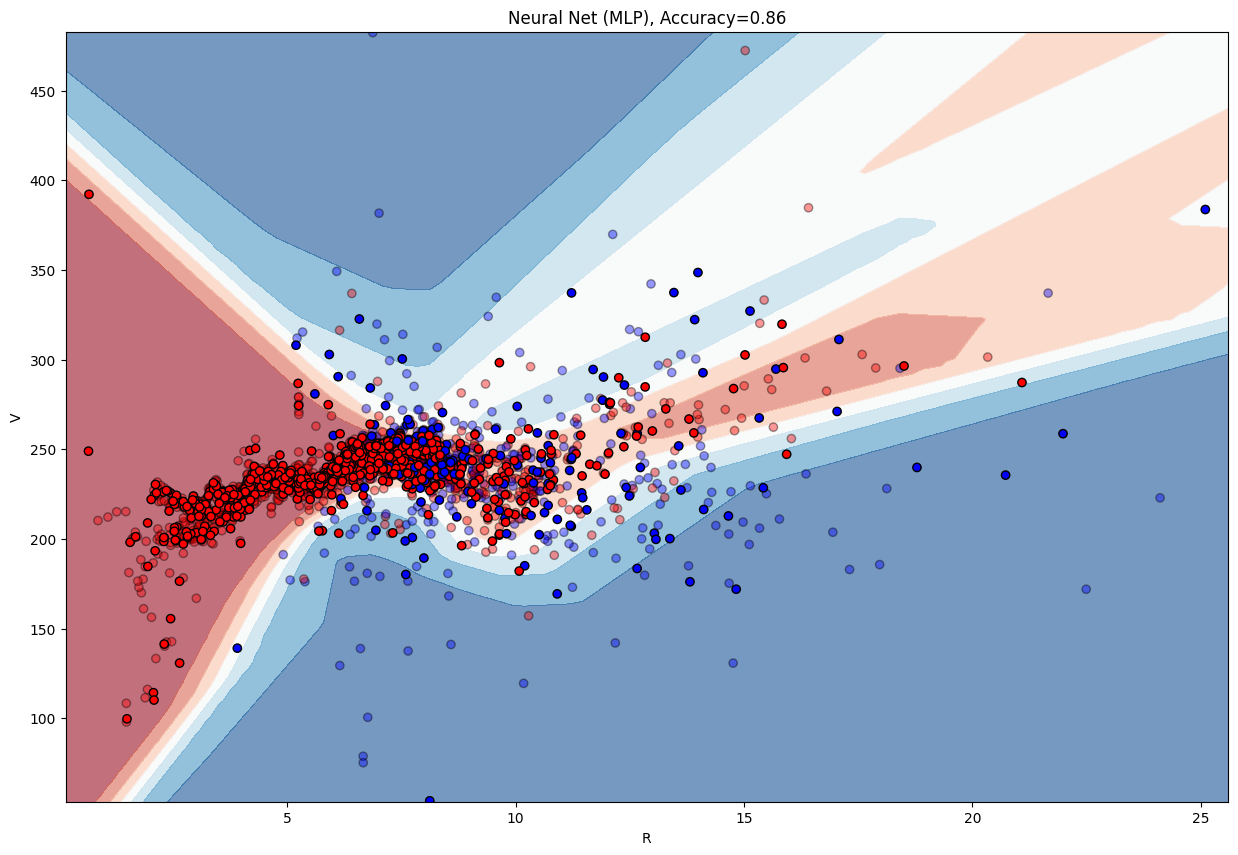

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay

# dane
file_path = "/content/drive/My Drive/r_v_montecarlo.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)

# ane wejściowe: R, V
X = df_all[['R', 'V']].values

# klasY
y = np.zeros(len(df_all), dtype=int)   # klasa 0
y[2217:2723] = 1                       # poprawne gwiazdy klasa 1

# podział na train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# model Neural Network
clf = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(20, 10), # warstwy neuronów
                  max_iter=1000, # maksymalna liczba iteracji uczenia
                  random_state=42) # ustawia losowość tak, żeby wyniki były powtarzalne
)
clf.fit(X_train, y_train) # uczenie modelu na danych treningowyc
score = clf.score(X_test, y_test)
print("Accuracy (MLP):", score)

# rysowanie granicy decyzyjnej
cm = plt.cm.RdBu
cm_bright = ListedColormap(["#FF0000", "#0000FF"])  # czerwony=klasa 0, niebieski=klasa 1

fig, ax = plt.subplots(figsize=(15, 10))

DecisionBoundaryDisplay.from_estimator(
    clf, X, cmap=cm, alpha=0.6, ax=ax, eps=0.5
)

# punkty treningowe
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, alpha=0.4, edgecolors="k")
# punkty testowe
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, edgecolors="k")

ax.set_xlabel("R")
ax.set_ylabel("V")
ax.set_title(f"Neural Net (MLP), Accuracy={score:.2f}")
plt.show()

/tmp/ipython-input-1585329724.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


Accuracy (MLP): 0.8705463182897862
Rozkład klas wg modelu: {np.int64(0): np.int64(2366), np.int64(1): np.int64(439)}


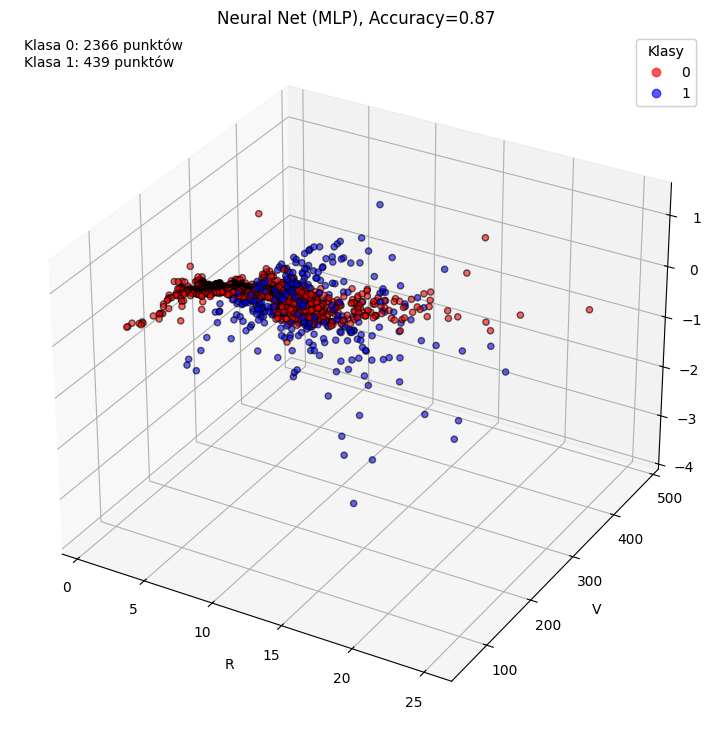

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# dane
file_path = "/content/drive/My Drive/r_v_z.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)

# dane wejściowe: R, V, z
X = df_all[['R', 'V', 'z']].values

# klasy
y = np.zeros(len(df_all), dtype=int)
y[2217:2723] = 1

# podział na train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# model Neural Net
clf = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(20, 10),  # warstwy neuronów
        max_iter=1000, # maksymalna liczba iteracji uczenia
        random_state=42 # ustawia losowość tak, żeby wyniki były powtarzalne
    )
)
clf.fit(X_train, y_train) # uczenie modelu na danych treningowyc
score = clf.score(X_test, y_test) # zwraca accuracy
print("Accuracy (MLP):", score)

# predykcje
y_pred = clf.predict(X) #każdy element to etykieta klasy przewidzianej przez model
unique, counts = np.unique(y_pred, return_counts=True) # liczba punktów w każdej klasie
class_distribution = dict(zip(unique, counts)) # łączy wartości i robi z nich slownik
print("Rozkład klas wg modelu:", class_distribution)

# wykres 3d
plt.ion()  # tryb interaktywny
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d") # okno z wykresem 3d, który można obracać myszką w trybie interaktywnym

# parametry jak mają punkty wyglądać
custom_cmap = ListedColormap(["red", "blue"]) # kolory punktów
scatter = ax.scatter(
    X[:, 0], X[:, 1], X[:, 2],
    c=y_pred, cmap=custom_cmap, marker="o", edgecolor="k", alpha=0.6
)

# etykiety osi
ax.set_xlabel("R")
ax.set_ylabel("V")
ax.set_zlabel("z")
ax.set_title(f"Neural Net (MLP), Accuracy={score:.2f}")

# legenda
legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Klasy",
    loc="upper right"
)
ax.add_artist(legend1)

# liczba punktów w każdej klasie
txt = "\n".join([f"Klasa {k}: {v} punktów" for k, v in class_distribution.items()])
ax.text2D(0.02, 0.95, txt, transform=ax.transAxes)

plt.show()

# NEURAL NETWORK - x, y, z

 Kolumny: ['R[kpc]', 'err_R[kpc]', 'D[kpc]', 'err_D[kpc]', 'l[deg]', 'b[deg]', 'x[kpc]', 'y[kpc]', 'z[kpc]', 'vx[km/s]', 'vRt[km/s]', 'err_vRt[km/s]', 'vz[km/s]', 'wc[km/s/kpc]', 'delta_wc[km/s/kpc]', 'Reference']
Accuracy (MLP): 0.8866348448687351
Rozkład klas wg modelu: {np.int64(0): np.int64(2362), np.int64(1): np.int64(430)}


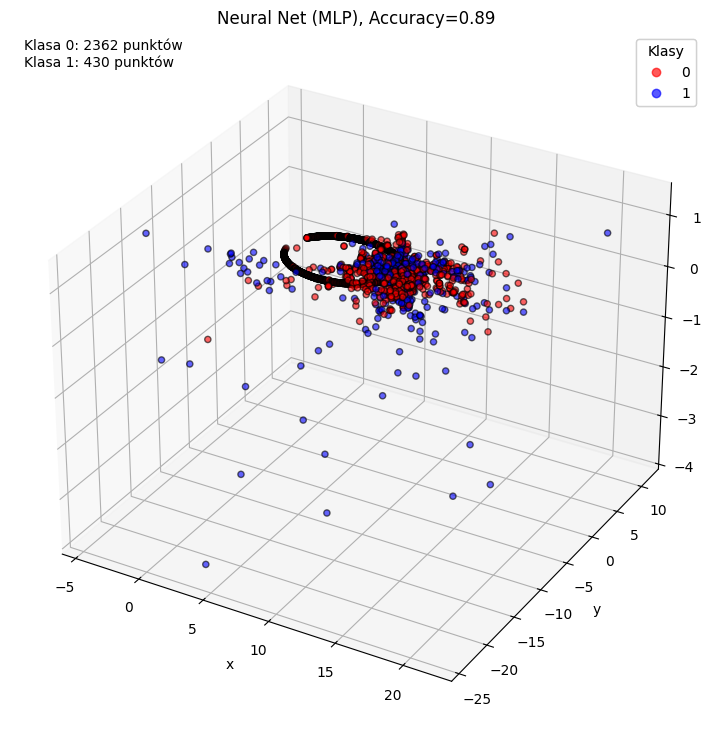

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

file_path = "/content/drive/My Drive/dane_obserwacyjne-kopia.dat"

# wczytanie linii z nagłówkami
with open(file_path) as f:
    lines = f.readlines()

# usunięcia nagłówka
header_line = [i for i, line in enumerate(lines) if line.strip().startswith("# R[kpc]")][0]
columns = lines[header_line].strip("# ").split()

# dane od następnej linii po nagłówku
df_all = pd.read_csv(file_path, sep=r"\s+", comment="#", names=columns, skiprows=header_line+1)
print(" Kolumny:", df_all.columns.tolist())

# dane
features = ["x[kpc]", "y[kpc]", "z[kpc]", "vRt[km/s]", "vz[km/s]"]
X = df_all[features].values

# klasy
y = np.zeros(len(df_all), dtype=int)
y[2217:2723] = 1

# podział na train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# model Neural Net
clf = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(20, 10),  # warstwy neuronów
        max_iter=1000, # maksymalna liczba iteracji uczenia
        random_state=42 # ustawia losowość tak, żeby wyniki były powtarzalne
    )
)
clf.fit(X_train, y_train) # uczenie modelu na danych treningowyc
score = clf.score(X_test, y_test) # zwraca accuracy
print("Accuracy (MLP):", score)

# predykcje
y_pred = clf.predict(X) #każdy element to etykieta klasy przewidzianej przez model
unique, counts = np.unique(y_pred, return_counts=True) # liczba punktów w każdej klasie
class_distribution = dict(zip(unique, counts)) # łączy wartości i robi z nich slownik
print("Rozkład klas wg modelu:", class_distribution)

# wykres 3d
plt.ion()  # tryb interaktywny
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d") # okno z wykresem 3d, który można obracać myszką w trybie interaktywnym

# parametry jak mają punkty wyglądać
custom_cmap = ListedColormap(["red", "blue"]) # kolory punktów
scatter = ax.scatter(
    X[:, 0], X[:, 1], X[:, 2],
    c=y_pred, cmap=custom_cmap, marker="o", edgecolor="k", alpha=0.6
)

# etykiety osi
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Neural Net (MLP), Accuracy={score:.2f}")

# legenda
legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Klasy",
    loc="upper right"
)
ax.add_artist(legend1)

# liczba punktów w każdej klasie
txt = "\n".join([f"Klasa {k}: {v} punktów" for k, v in class_distribution.items()])
ax.text2D(0.02, 0.95, txt, transform=ax.transAxes)

plt.show()

# LDA - R, V, z

/tmp/ipython-input-2020888986.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


Accuracy (LDA): 0.8266033254156769


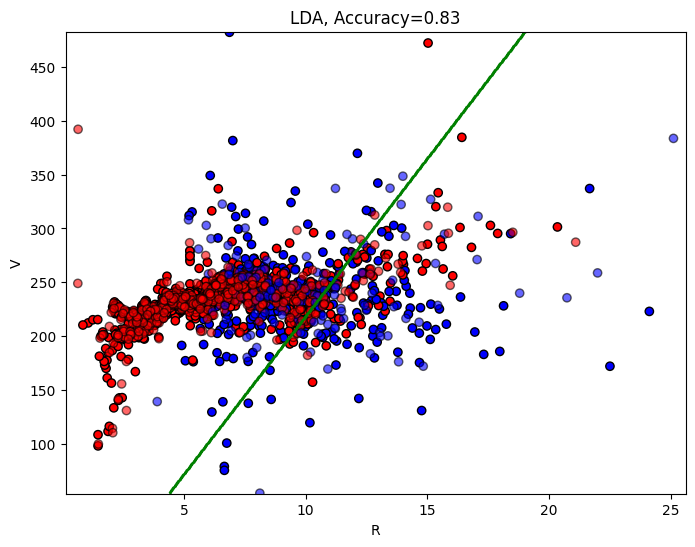

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

# dane
file_path = "/content/drive/My Drive/r_v_montecarlo.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)

# dane wejściowe: R, V
X = df_all[['R', 'V']].values

# klasy
y = np.zeros(len(df_all), dtype=int)   # klasa 0
y[2217:2723] = 1                       # poprawne gwiazdy klasa 1

# podział na train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# model LDA
clf = LinearDiscriminantAnalysis() # obiekt klasyfikatora LDA, próbuje znaleźć najlepszą prostą linię (w 2D)
clf.fit(X_train, y_train) # model analizuje, jak rozkładają się punkty klas 0 i 1 i oblicza linię graniczną, która je najlepiej oddziela

# dokładność
score = clf.score(X_test, y_test)
print("Accuracy (LDA):", score)

# rysowanie granicy decyzyjnej
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5 # szukanie minimalnej i maksymalnej wartości R i V, odejmowanie/dodawanie 0.5, żeby mieć trochę marginesu wokół punktów
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500), # siatka punktów 500×500, czyli 250 000 punktów.
    np.linspace(y_min, y_max, 500)
)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8,6))

# granica decyzyjna jako kontur
ax.contour(xx, yy, Z, levels=[0.5], colors="green", linewidths=2)

# punkty danych
cm_bright = ListedColormap(["#FF0000", "#0000FF"])
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, edgecolors="k", alpha=0.6)

ax.set_xlabel("R")
ax.set_ylabel("V")
ax.set_title(f"LDA, Accuracy={score:.2f}")
plt.show()

/tmp/ipython-input-3816729893.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_all = pd.read_csv(file_path, delim_whitespace=True)


Accuracy (LDA): 0.8254156769596199
Rozkład klas wg modelu: {np.int64(0): np.int64(2554), np.int64(1): np.int64(251)}


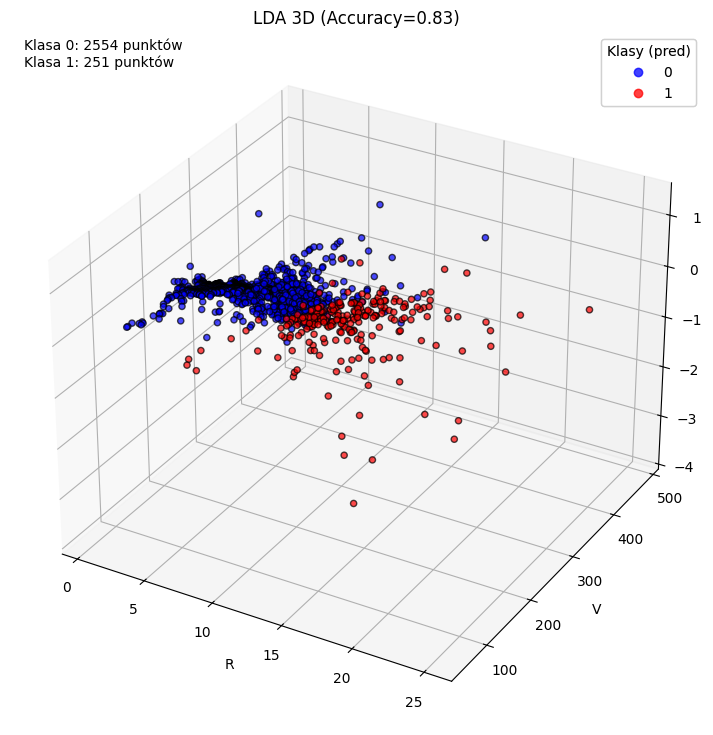

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

# danr
file_path = "/content/drive/My Drive/r_v_z.dat"
df_all = pd.read_csv(file_path, delim_whitespace=True)

# dane wejściowe: R, V, z
X = df_all[['R', 'V', 'z']].values

# klasy
y = np.zeros(len(df_all), dtype=int)
y[2217:2723] = 1                       # poprawne gwiazdy

# podział na train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# model LDA
clf = LinearDiscriminantAnalysis()
clf.fit(X_train, y_train) # uczenie modelu na danych treningowyc

# dokładność
score = clf.score(X_test, y_test)
print("Accuracy (LDA):", score)

# predykcje
y_pred = clf.predict(X) #każdy element to etykieta klasy przewidzianej przez model
unique, counts = np.unique(y_pred, return_counts=True) # liczba punktów w każdej klasie
class_distribution = dict(zip(unique, counts)) # łączy wartości i robi z nich slownik
print("Rozkład klas wg modelu:", class_distribution)

# wykres 3d
plt.ion()  # tryb interaktywny
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# parametry jak mają punkty wyglądać
custom_cmap = ListedColormap(["blue", "red"]) # kolory punktów
scatter = ax.scatter(
    X[:, 0], X[:, 1], X[:, 2], c=y_pred, cmap=custom_cmap, marker="o", edgecolor="k", alpha=0.7
)

# etykiety osi
ax.set_xlabel("R")
ax.set_ylabel("V")
ax.set_zlabel("z")
ax.set_title(f"LDA 3D (Accuracy={score:.2f})")

# legenda
legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Klasy (pred)",
    loc="upper right"
)
ax.add_artist(legend1)

# liczba punktów w każdej klasie
txt = "\n".join([f"Klasa {k}: {v} punktów" for k, v in class_distribution.items()])
ax.text2D(0.02, 0.95, txt, transform=ax.transAxes)

plt.show()

# LDA - x, y, z

 Kolumny: ['R[kpc]', 'err_R[kpc]', 'D[kpc]', 'err_D[kpc]', 'l[deg]', 'b[deg]', 'x[kpc]', 'y[kpc]', 'z[kpc]', 'vx[km/s]', 'vRt[km/s]', 'err_vRt[km/s]', 'vz[km/s]', 'wc[km/s/kpc]', 'delta_wc[km/s/kpc]', 'Reference']
Accuracy (LDA): 0.8210023866348448
Rozkład klas wg modelu: {np.int64(0): np.int64(2564), np.int64(1): np.int64(228)}


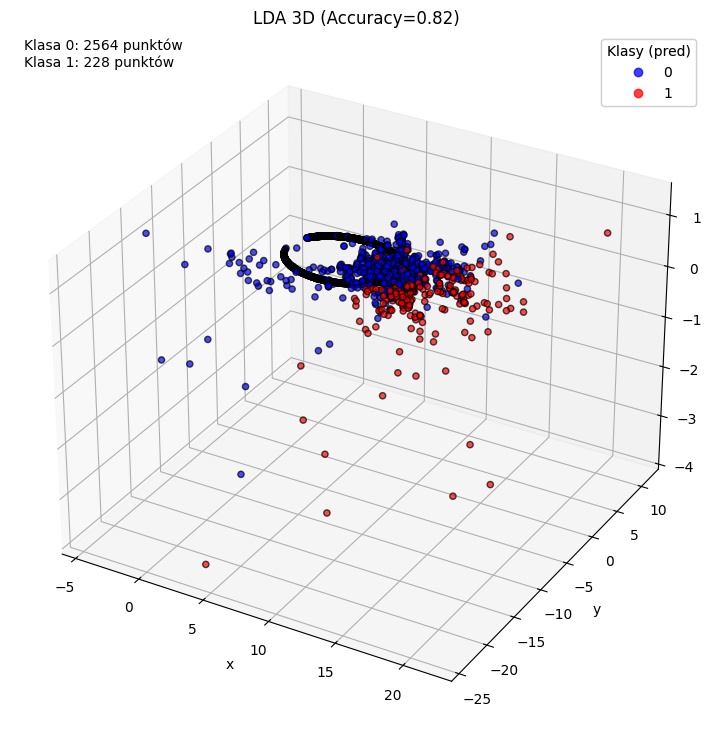

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

file_path = "/content/drive/My Drive/dane_obserwacyjne-kopia.dat"

# wczytanie linii z nagłówkami
with open(file_path) as f:
    lines = f.readlines()

# usunięcia nagłówka
header_line = [i for i, line in enumerate(lines) if line.strip().startswith("# R[kpc]")][0]
columns = lines[header_line].strip("# ").split()

# dane od następnej linii po nagłówku
df_all = pd.read_csv(file_path, sep=r"\s+", comment="#", names=columns, skiprows=header_line+1)
print(" Kolumny:", df_all.columns.tolist())

# dane
features = ["x[kpc]", "y[kpc]", "z[kpc]", "vRt[km/s]", "vz[km/s]"]
X = df_all[features].values

# klasy
y = np.zeros(len(df_all), dtype=int)
y[2217:2723] = 1                       # poprawne gwiazdy


#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

# podział na train i test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# model LDA
clf = LinearDiscriminantAnalysis()
clf.fit(X_train, y_train) # uczenie modelu na danych treningowyc

# dokładność
score = clf.score(X_test, y_test)
print("Accuracy (LDA):", score)

# predykcje
y_pred = clf.predict(X) #każdy element to etykieta klasy przewidzianej przez model
unique, counts = np.unique(y_pred, return_counts=True) # liczba punktów w każdej klasie
class_distribution = dict(zip(unique, counts)) # łączy wartości i robi z nich slownik
print("Rozkład klas wg modelu:", class_distribution)

# wykres 3d
plt.ion()  # tryb interaktywny
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# parametry jak mają punkty wyglądać
custom_cmap = ListedColormap(["blue", "red"]) # kolory punktów
scatter = ax.scatter(
    X[:, 0], X[:, 1], X[:, 2], c=y_pred, cmap=custom_cmap, marker="o", edgecolor="k", alpha=0.7
)

# etykiety osi
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"LDA 3D (Accuracy={score:.2f})")

# legenda
legend1 = ax.legend(
    *scatter.legend_elements(),
    title="Klasy (pred)",
    loc="upper right"
)
ax.add_artist(legend1)

# liczba punktów w każdej klasie
txt = "\n".join([f"Klasa {k}: {v} punktów" for k, v in class_distribution.items()])
ax.text2D(0.02, 0.95, txt, transform=ax.transAxes)

plt.show()
